In [42]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [50]:
# === User settings ===

# Folder containing simulation output folders.
# This folder should contain subfolders, each with:
#   input.json
#   Order_parameters.txt
RUN_DIR = Path("../example_slurm")

# Where to write the compact summary table
SUMMARY_FILE = Path("polarization_summary.txt")

# Fraction of the final time series used for late-time averaging
WINDOW_FRACTION = 0.10

# Output figure folder
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [44]:
def read_order_parameters(path):
    """
    Read Order_parameters.txt and return a 2D NumPy array.

    Expected column convention:
        column 0: polarization
    """
    data = np.loadtxt(path, skiprows=1)

    if data.ndim == 1:
        data = np.expand_dims(data, axis=0)

    return data


def summarize_single_simulation(input_json_path, window_fraction=0.10):
    """
    Read one simulation folder and compute late-time averages.
    """
    run_folder = input_json_path.parent
    order_parameter_path = run_folder / "Order_parameters.txt"

    if not order_parameter_path.is_file():
        print(f"Skipping {run_folder}: missing Order_parameters.txt")
        return None

    try:
        with input_json_path.open("r") as f:
            params = json.load(f)
    except Exception as exc:
        print(f"Skipping {run_folder}: could not read input.json: {exc}")
        return None

    try:
        data = read_order_parameters(order_parameter_path)
    except Exception as exc:
        print(f"Skipping {run_folder}: could not read Order_parameters.txt: {exc}")
        return None

    if len(data) < 2:
        print(f"Skipping {run_folder}: not enough time points")
        return None

    start = int((1.0 - window_fraction) * len(data))
    start = max(start, 0)
    late_time = data[start:]

    # Adapt these column meanings if your Order_parameters.txt has a different convention.
    polarization = late_time[:, 0]

    row = {
        "folder": str(run_folder),
        "N": int(params.get("N", -1)),
        "D_0": float(params.get("D_0", np.nan)),
        "v_0": float(params.get("v_0", np.nan)),
        "range": float(params.get("range", np.nan)),
        "delta_t": float(params.get("delta_t", np.nan)),
        "dt": float(params.get("dt", np.nan)),
        "J": float(params.get("J", np.nan)),
        "polarization": float(np.mean(polarization)),
        "pol_var": float(np.var(polarization)),
    }

    return row


def summarize_run_folder(run_dir, summary_file, window_fraction=0.10):
    """
    Search run_dir for input.json files and summarize all completed simulations.
    """
    run_dir = Path(run_dir)
    summary_file = Path(summary_file)

    input_files = sorted(run_dir.rglob("input.json"))

    if not input_files:
        raise FileNotFoundError(f"No input.json files found below {run_dir}")

    rows = []

    for input_json_path in input_files:
        row = summarize_single_simulation(
            input_json_path=input_json_path,
            window_fraction=window_fraction,
        )

        if row is not None:
            rows.append(row)

    if not rows:
        raise RuntimeError("No valid simulation folders were summarized.")

    df = pd.DataFrame(rows)
    df = df.sort_values(["D_0", "delta_t", "J", "v_0"])

    summary_file.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(summary_file, sep=" ", index=False)

    print(f"Processed {len(df)} simulation folders.")
    print(f"Wrote summary to: {summary_file}")

    return df

In [45]:
def load_summary(summary_file):
    """
    Load the compact summary table.
    """
    summary_file = Path(summary_file)
    df = pd.read_csv(summary_file, sep=r"\s+")

    required = {"D_0", "delta_t", "polarization", "pol_var"}
    missing = required.difference(df.columns)

    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    return df


def filter_summary(df, fixed_D0=None, fixed_J=None, fixed_v0=None):
    """
    Optionally restrict the data to one parameter slice.
    """
    out = df.copy()

    if fixed_D0 is not None:
        out = out[np.isclose(out["D_0"], fixed_D0)]

    if fixed_J is not None and "J" in out.columns:
        out = out[np.isclose(out["J"], fixed_J)]

    if fixed_v0 is not None and "v_0" in out.columns:
        out = out[np.isclose(out["v_0"], fixed_v0)]

    if out.empty:
        raise ValueError("No data left after filtering.")

    return out


def aggregate_summary(df, observable="polarization"):
    """
    Average repeated simulations with the same D_0 and delta_t.

    This is useful if you later run multiple seeds or repeated jobs.
    """
    if observable not in df.columns:
        raise ValueError(f"Observable '{observable}' not found in dataframe.")

    agg_dict = {
        observable: "mean",
    }

    if "pol_var" in df.columns:
        agg_dict["pol_var"] = "mean"

    grouped = (
        df.groupby(["D_0", "delta_t"], as_index=False)
        .agg(agg_dict)
        .sort_values(["D_0", "delta_t"])
    )

    return grouped

In [46]:
def plot_polarization_vs_delta_t(
    df,
    observable="polarization",
    use_errorbars=True,
    output_file=None,
):
    """
    Plot observable versus delta_t.

    If several D_0 values are present, one curve is shown for each D_0.
    """
    fig, ax = plt.subplots(figsize=(5.0, 3.5))

    for D0, subset in df.groupby("D_0"):
        subset = subset.sort_values("delta_t")

        x = subset["delta_t"].to_numpy()
        y = subset[observable].to_numpy()

        if (
            use_errorbars
            and observable == "polarization"
            and "pol_var" in subset.columns
        ):
            yerr = np.sqrt(subset["pol_var"].to_numpy())
            ax.errorbar(
                x,
                y,
                yerr=yerr,
                marker="o",
                capsize=3,
                label=rf"$D_0={D0:g}$",
            )
        else:
            ax.plot(
                x,
                y,
                marker="o",
                label=rf"$D_0={D0:g}$",
            )

    ax.set_xlabel(r"Delay time $\tau$")
    ax.set_ylabel("Polarization" if observable == "polarization" else observable)
    ax.set_ylim(bottom=0)

    if df["D_0"].nunique() > 1:
        ax.legend(frameon=False)

    fig.tight_layout()

    if output_file is not None:
        output_file = Path(output_file)
        output_file.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {output_file}")

    return fig, ax

In [54]:
def plot_polarization_3d(
    df,
    observable="polarization",
    output_file=None,
):
    """
    Plot observable as a function of D_0 and delta_t.

    This uses scatter points and connecting lines, which works even if the
    D_0-delta_t grid is incomplete.
    """
    fig = plt.figure(figsize=(5.5, 4.3))
    ax = fig.add_subplot(projection="3d")

    x = df["D_0"].to_numpy()
    y = df["delta_t"].to_numpy()
    z = df[observable].to_numpy()

    ax.scatter(x, y, z, marker="o")

    for D0, subset in df.groupby("D_0"):
        subset = subset.sort_values("delta_t")
        ax.plot(
            subset["D_0"].to_numpy(),
            subset["delta_t"].to_numpy(),
            subset[observable].to_numpy(),
            marker="o",
            label=rf"$D_0={D0:g}$",
        )

    ax.set_xlabel(r"Noise strength $D_0$")
    ax.set_ylabel(r"Delay time $\tau$")
    ax.set_zlabel("Polarization" if observable == "polarization" else observable)

    ax.view_init(elev=30, azim=135)

    fig.tight_layout()

    if output_file is not None:
        output_file = Path(output_file)
        output_file.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_file, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {output_file}")

    return fig, ax

Saved figure to: figures/polarization_D0_delta_t_2d.png
Saved figure to: figures/polarization_D0_delta_t_3d.png


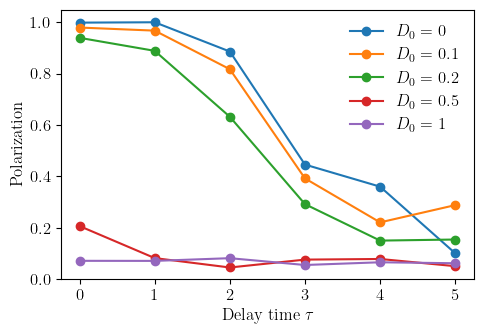

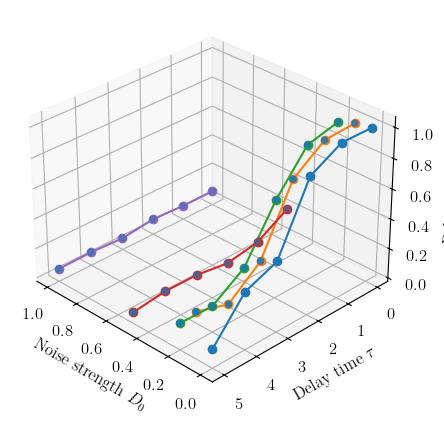

In [ ]:
summary = load_summary(SUMMARY_FILE)
summary_agg = aggregate_summary(summary, observable="polarization")

fig, ax = plot_polarization_vs_delta_t(
    summary_agg,
    observable="polarization",
    output_file=FIGURE_DIR / "polarization_D0_delta_t_2d.png",
    use_errorbars=1
)

fig, ax = plot_polarization_3d(
    summary_agg,
    observable="polarization",
    output_file=FIGURE_DIR / "polarization_D0_delta_t_3d.png",
)
